## 1. 数据处理

先导入后续所需的库，设置Dataframe的显示格式。

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#显示 DataFrame 时，不限制列数，展示所有字段
pd.set_option("display.max_columns", None)
#文本形式表格的显示宽度设为 120 个字符
pd.set_option("display.width", 120)

print("Pandas 版本：", pd.__version__)
print("当前工作目录：", Path.cwd())

Pandas 版本： 3.0.5
当前工作目录： /Users/clearlove7/Documents/AI introduction/Hull Tactical Competition/notebooks


导入数据并对数据做初步认知。

In [4]:
df = pd.read_csv("../archive/spy-historical.csv")

#显示前五行
display(df.head())

print("数据行数：", df.shape[0])
print("数据列数：", df.shape[1])

#把全部字段名称转换成普通列表
print("字段名称：")
print(df.columns.tolist())

#返回每列是否有空值，以及数据类型
df.info()

,date_id,Date,Open,High,Low,Close,Adj Close,Volume,Dividend,forward_returns
0,780,1993-02-01,43.97,44.25,43.97,44.25,24.49,480500.0,0.0,0.002034
1,781,1993-02-02,44.22,44.38,44.13,44.34,24.54,201300.0,0.0,0.010600
2,782,1993-02-03,44.41,44.84,44.38,44.81,24.80,529400.0,0.0,0.004240
3,783,1993-02-04,44.97,45.09,44.47,45.00,24.90,531500.0,0.0,-0.000667
4,784,1993-02-05,44.97,45.06,44.72,44.97,24.88,492100.0,0.0,0.000000


数据行数： 8210
数据列数： 10
字段名称：
['date_id', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Dividend', 'forward_returns']
<class 'pandas.DataFrame'>
RangeIndex: 8210 entries, 0 to 8209
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date_id          8210 non-null   int64  
 1   Date             8210 non-null   str    
 2   Open             8210 non-null   float64
 3   High             8210 non-null   float64
 4   Low              8210 non-null   float64
 5   Close            8210 non-null   float64
 6   Adj Close        8210 non-null   float64
 7   Volume           8210 non-null   float64
 8   Dividend         8210 non-null   float64
 9   forward_returns  8209 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 641.5 KB


可以看到除了forward_returns以外，每列一共8210个数据，无空值。由于forward_return是未来反馈，交易日无下一日信息，少1个数据属正常现象。下面将数据集spy-historical.csv的前80%数据划分为训练集，后20%划分为测试集。

In [5]:
# 把字符串转换为真正的日期类型
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%Y-%m-%d",
    errors="raise"
)

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("训练集形状：", train_df.shape)
print("训练集日期：", train_df["Date"].iloc[0], "至", train_df["Date"].iloc[-1])

print("测试集形状：", test_df.shape)
print("测试集日期：", test_df["Date"].iloc[0], "至", test_df["Date"].iloc[-1])

训练集形状： (6568, 10)
训练集日期： 1993-02-01 00:00:00 至 2019-03-01 00:00:00
测试集形状： (1642, 10)
测试集日期： 2019-03-04 00:00:00 至 2025-09-11 00:00:00


## 2. 逻辑回归

#### 2.1 数据分析与特征构建

先计算收益率，其中Close是当天市场收盘价，Adj Close是经过拆股、分红等因素调整后的价格。我们研究的是投资者实际获得的历史收益，因此使用 Adj Close 计算收益率更合理。

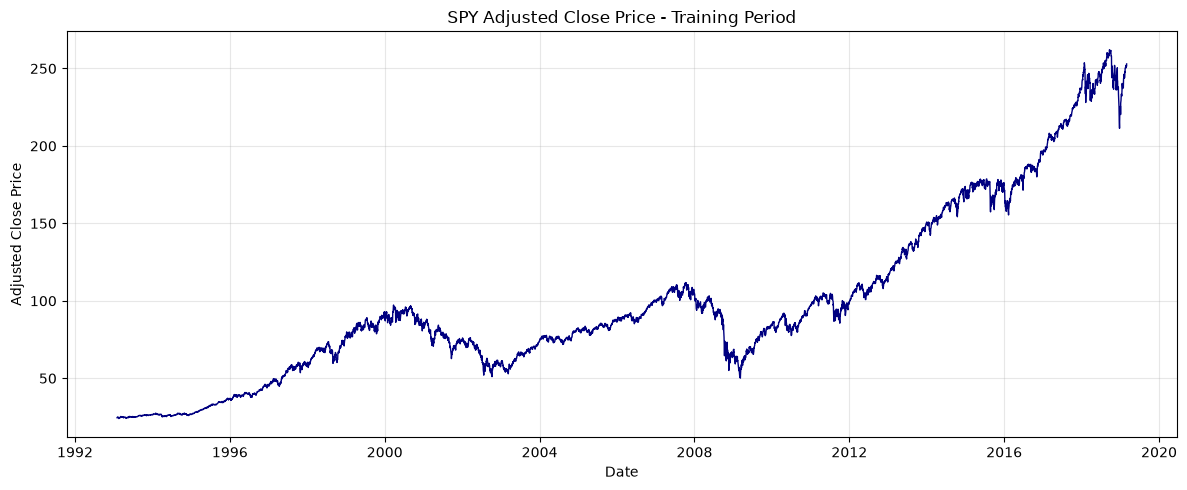

count    6567.000000
mean        0.000422
std         0.011524
min        -0.098435
25%        -0.004325
50%         0.000648
75%         0.005760
max         0.145291
Name: Daily_Return, dtype: float64

In [6]:
#计算每日收益率
train_df["Daily_Return"] = train_df["Adj Close"].pct_change()

#绘制复权收盘价曲线
plt.figure(figsize=(12, 5))

plt.plot(
    train_df["Date"],
    train_df["Adj Close"],
    color="navy",
    linewidth=1
)

plt.title("SPY Adjusted Close Price - Training Period")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#查看收益率统计
train_df["Daily_Return"].describe()

可以从收益率的数据看出，年化平均收益约为：0.000422 × 252 = 10.63%，年化波动率约为：0.011524 × √252 = 18.29%。同时可以看出SPY虽然长期有正收益，但单日的随机波动远大于平均上涨幅度，所以预测下一日涨跌非常困难。

In [7]:
daily_returns = train_df["Daily_Return"].dropna()

up_days = (daily_returns > 0).sum()
down_days = (daily_returns < 0).sum()
flat_days = (daily_returns == 0).sum()

up_rate = up_days / len(daily_returns)
down_rate = down_days / len(daily_returns)
flat_rate = flat_days / len(daily_returns)

print("上涨日数量：", up_days)
print("下跌日数量：", down_days)
print("平盘日数量：", flat_days)

print("上涨日比例：", f"{up_rate:.2%}")
print("下跌日比例：", f"{down_rate:.2%}")
print("平盘日比例：", f"{flat_rate:.2%}")

上涨日数量： 3523
下跌日数量： 2969
平盘日数量： 75
上涨日比例： 53.65%
下跌日比例： 45.21%
平盘日比例： 1.14%


我们做一个小验算，数据集中forward_returns通常有多种含义，或者说计算方式，例如
1. 下一日收盘价收益
2. 下一日含分红收益
3. 下一日开盘到收盘收益
4. 简单收益率
5. 对数收益率

经过以下验证，可以确认此刻采用的是第二种，下一日含分红收益在这份数据中的定义是：
$$
forward\_returns_t
=
\frac{Close_{t+1}+Dividend_{t+1}}{Close_t}-1
$$
也就是“从今天收盘持有到下一交易日收盘的含分红简单收益率”。

In [8]:
calculated_forward_returns = (
    (
        df["Close"].shift(-1)
        + df["Dividend"].shift(-1)
    )
    / df["Close"]
    - 1
)

max_difference = (
    df["forward_returns"]
    - calculated_forward_returns
).abs().max()

print("最大计算误差：", max_difference)

最大计算误差： 9.996344030316351e-17


接下来我们要回答下一个问题：已知今天收盘时及以前的信息，SPY 下一个交易日会上涨吗？这需要我们数据中的forward_returns表示当前行对应的下一交易日收益率。因此标签定义为：
$$
target =
\begin{cases}
1, & forward\_returns > 0 \\
0, & forward\_returns \le 0
\end{cases}
$$其中：
target = 1：下一日上涨；
target = 0：下一日下跌或平盘。
模型以后使用当前行的历史特征预测当前行的 target。
最后一个交易日没有下一日收益，因此不能作为训练样本。在这一步，我们会计算所有数据的整体特征。之后再分别划分进训练集和测试集。

In [9]:
#删去最后一个交易日
model_df = df.dropna(subset=["forward_returns"]).copy()

model_df["target"] = (
    model_df["forward_returns"] > 0
).astype(int)

display(
    model_df[
        ["Date", "Adj Close", "forward_returns", "target"]
    ].head()
)

,Date,Adj Close,forward_returns,target
0,1993-02-01,24.49,0.002034,1
1,1993-02-02,24.54,0.010600,1
2,1993-02-03,24.80,0.004240,1
3,1993-02-04,24.90,-0.000667,0
4,1993-02-05,24.88,0.000000,0


在接下来的步骤中，我们构建11个模型特征用于之后训练模型。包括：1日、5日、20日历史收益率，5日、20日、60日均线距离，5日、20日滚动波动率，日内收益率，日内振幅，20日相对成交量。

我们使用历史收益率来描述近期市场状态，以下我们分别计算1日，5日，20日历史收益率。

1日历史收益率
$$
return\_1d_t
=
\frac{AdjClose_t}{AdjClose_{t-1}}-1
$$

5日历史收益率
$$
return\_5d_t
=
\frac{AdjClose_t}{AdjClose_{t-5}}-1
$$

20日历史收益率
$$
return\_20d_t
=
\frac{AdjClose_t}{AdjClose_{t-20}}-1
$$

In [10]:
model_df["return_1d"] = (
    model_df["Adj Close"].pct_change(1)
)

model_df["return_5d"] = (
    model_df["Adj Close"].pct_change(5)
)

model_df["return_20d"] = (
    model_df["Adj Close"].pct_change(20)
)

display(
    model_df[
        [
            "Date",
            "Adj Close",
            "return_1d",
            "return_5d",
            "return_20d"
        ]
    ].iloc[18:23]
)

,Date,Adj Close,return_1d,return_5d,return_20d
18,1993-02-26,24.57,0.001222,0.019079,NaN
19,1993-03-01,24.50,-0.002849,0.012815,NaN
20,1993-03-02,24.87,0.015102,0.028962,0.015517
21,1993-03-03,24.97,0.004021,0.019600,0.017522
22,1993-03-04,24.83,-0.005607,0.011817,0.001210


我们使用移动平均线描述当前价格相对于近期趋势的位置。移动平均线就是过去若干交易日价格的平均值：
$$
MA_{20,t}
=
\frac{P_t+P_{t-1}+\cdots+P_{t-19}}{20}
$$
我们使用三个周期：
1. 5日均线：约一周的短期趋势
2. 20日均线：约一个月的中期趋势
3. 60日均线：约一个季度的较长期趋势

In [11]:
#计算均线
model_df["ma_5"] = (
    model_df["Adj Close"].rolling(5).mean()
)

model_df["ma_20"] = (
    model_df["Adj Close"].rolling(20).mean()
)

model_df["ma_60"] = (
    model_df["Adj Close"].rolling(60).mean()
)

#计算当前价格和均线的距离
model_df["distance_ma_5"] = (
    model_df["Adj Close"] / model_df["ma_5"] - 1
)

model_df["distance_ma_20"] = (
    model_df["Adj Close"] / model_df["ma_20"] - 1
)

model_df["distance_ma_60"] = (
    model_df["Adj Close"] / model_df["ma_60"] - 1
)

#查看60个交易日前后的结果
display(
    model_df[
        [
            "Date",
            "Adj Close",
            "ma_5",
            "ma_20",
            "ma_60",
            "distance_ma_5",
            "distance_ma_20",
            "distance_ma_60"
        ]
    ].iloc[58:63]
)

,Date,Adj Close,ma_5,ma_20,ma_60,distance_ma_5,distance_ma_20,distance_ma_60
58,1993-04-26,24.13,24.476,24.7775,NaN,-0.014136,-0.026133,NaN
59,1993-04-27,24.39,24.402,24.7435,24.759833,-0.000492,-0.014287,-0.014937
60,1993-04-28,24.34,24.322,24.7035,24.757333,0.000740,-0.014715,-0.016857
61,1993-04-29,24.45,24.326,24.6700,24.755833,0.005097,-0.008918,-0.012354
62,1993-04-30,24.48,24.358,24.6420,24.750500,0.005009,-0.006574,-0.010929


历史收益率描述市场过去涨跌了多少，但不能描述上涨或下跌过程是否稳定。因此需构建滚动波动率，例如，两段时间的5日总收益都是2%：
1. 每天平稳小幅上涨
2. 先大跌、再大涨，最终上涨2%

两段的累计收益相同，但第二段风险和不确定性更高。这种差异由波动率描述。滚动波动率就是过去若干交易日收益率的标准差：
$$
volatility_{20,t}
=
Std(r_t,r_{t-1},\ldots,r_{t-19})
$$

波动率越高，说明近期每日收益变化越剧烈；波动率越低，说明近期市场相对平稳。

In [12]:
#滚动波动率
model_df["volatility_5d"] = (
    model_df["return_1d"].rolling(5).std()
)

model_df["volatility_20d"] = (
    model_df["return_1d"].rolling(20).std()
)

display(
    model_df[
        [
            "Date",
            "return_1d",
            "volatility_5d",
            "volatility_20d"
        ]
    ].iloc[18:23]
)

,Date,return_1d,volatility_5d,volatility_20d
18,1993-02-26,0.001222,0.005488,NaN
19,1993-03-01,-0.002849,0.006262,NaN
20,1993-03-02,0.015102,0.007933,0.008420
21,1993-03-03,0.004021,0.006739,0.008447
22,1993-03-04,-0.005607,0.008016,0.008243


使用日内收益率和日内振幅，判断当天开盘后市场发生了什么。

日内收益率
$$
intraday\_return_t
=
\frac{Close_t}{Open_t}-1
$$

它表示当天开盘到收盘的涨跌。

日内振幅

$$
daily\_range_t
=
\frac{High_t-Low_t}{Close_t}
$$

它描述当天最高价和最低价之间的价格跨度。日内收益率提供方向，日内振幅提供波动程度。

In [13]:
#日内收益率
model_df["intraday_return"] = (
    model_df["Close"] / model_df["Open"] - 1
)

#日内振幅
model_df["daily_range"] = (
    (model_df["High"] - model_df["Low"])
    / model_df["Close"]
)

display(
    model_df[
        [
            "Date",
            "Open",
            "High",
            "Low",
            "Close",
            "intraday_return",
            "daily_range"
        ]
    ].head()
)

,Date,Open,High,Low,Close,intraday_return,daily_range
0,1993-02-01,43.97,44.25,43.97,44.25,0.006368,0.006328
1,1993-02-02,44.22,44.38,44.13,44.34,0.002714,0.005638
2,1993-02-03,44.41,44.84,44.38,44.81,0.009007,0.010266
3,1993-02-04,44.97,45.09,44.47,45.00,0.000667,0.013778
4,1993-02-05,44.97,45.06,44.72,44.97,0.000000,0.007561


20日相对成交量用于衡量今天的市场交易活跃程度，相对于最近约一个月是高还是低？原始 Volume 不能直接跨时期比较。因为随着 SPY 市场规模和交易活跃度变化，1990年代和现在的成交量水平差异很大。
因此先计算20日平均成交量：
$$
volume\_ma_{20,t}
=
\frac{Volume_t+Volume_{t-1}+\cdots+Volume_{t-19}}{20}
$$

再计算相对成交量：
$$
volume\_ratio_{20d,t}
=
\frac{Volume_t}{volume\_ma_{20,t}}
$$

In [14]:
#20日平均成交量
model_df["volume_ma_20"] = (
    model_df["Volume"].rolling(20).mean()
)

#20日相对成交量
model_df["volume_ratio_20d"] = (
    model_df["Volume"] / model_df["volume_ma_20"]
)

display(
    model_df[
        [
            "Date",
            "Volume",
            "volume_ma_20",
            "volume_ratio_20d"
        ]
    ].iloc[18:23]
)

,Date,Volume,volume_ma_20,volume_ratio_20d
18,1993-02-26,66200.0,NaN,NaN
19,1993-03-01,66500.0,274205.0,0.242519
20,1993-03-02,182400.0,259300.0,0.703432
21,1993-03-03,280100.0,263240.0,1.064048
22,1993-03-04,89500.0,241245.0,0.370992


#### 2.2 模型训练

我们已经完成了对模型特征的收集，接下来我们开始训练模型。

In [15]:
#明确模型特征
feature_columns = [
    "return_1d",
    "return_5d",
    "return_20d",
    "distance_ma_5",
    "distance_ma_20",
    "distance_ma_60",
    "volatility_5d",
    "volatility_20d",
    "intraday_return",
    "daily_range",
    "volume_ratio_20d"
]

#删除空白值
model_data = model_df.dropna(
    subset=feature_columns
).copy()

print("清理前样本数：", len(model_df))
print("清理后样本数：", len(model_data))

#按原日期重新划分训练集
split_date = test_df["Date"].iloc[0]

train_model = model_data[
    model_data["Date"] < split_date
].copy()

test_model = model_data[
    model_data["Date"] >= split_date
].copy()

#设立输入和目标
X_train = train_model[feature_columns]
y_train = train_model["target"]

X_test = test_model[feature_columns]
y_test = test_model["target"]

#确认最终数据涉及的时间范围是否符合
print("X_train：", X_train.shape)
print("y_train：", y_train.shape)
print(
    "训练日期：",
    train_model["Date"].iloc[0],
    "至",
    train_model["Date"].iloc[-1]
)

print("X_test：", X_test.shape)
print("y_test：", y_test.shape)
print(
    "测试日期：",
    test_model["Date"].iloc[0],
    "至",
    test_model["Date"].iloc[-1]
)

清理前样本数： 8209
清理后样本数： 8150
X_train： (6509, 11)
y_train： (6509,)
训练日期： 1993-04-27 00:00:00 至 2019-03-01 00:00:00
X_test： (1641, 11)
y_test： (1641,)
测试日期： 2019-03-04 00:00:00 至 2025-09-10 00:00:00


SPY上涨日通常多于下跌日。因此，即使完全不分析任何特征，每天都预测“明天上涨”，准确率也可能超过50%。我们的模型必须超过这个简单的准则。我们首先使用训练集确定基线，而后生成逻辑回归预测，再同时比较两者的测试集表现。最开始选择逻辑回归的原因，是因为他专门处理二分问题，同时能直接输出上涨或下降的概率，训练速度快，系数的可解释性很强，模型复杂度低，在金融这种信号弱、噪声大的数据中，是合理的基础模型。然而逻辑回归只能处理线性问题，例如波动率越高，他会倾向于预测上涨概率更高或更低，但有时候，波动率中等的上涨概率更高，这种非线性关系是逻辑回归无法预测的。与此同时，那种复杂因素结合导致的结果，他也难以预测，比如当20日交易率很高时，一些信号对预测上涨才有帮助。这些问题我们会在下一个模型进一步处理。

逻辑回归会给每个特征学习一个系数：
$$
z
=
\beta_0
+
\beta_1x_1
+
\beta_2x_2
+\cdots+
\beta_{11}x_{11}
$$
其中：
$x_1,\ldots,x_{11}$是11个特征，
$\beta_1,\ldots,\beta_{11}$是模型学习出来的系数，
$\beta_0$是截距，
$z$是所有特征形成的综合分数。

综合分数 $z$ 可以是任意数，例如 -2、0.3 或 4。但上涨概率必须在0和1之间。
逻辑回归使用 Sigmoid 函数：
$$
P(target=1)
=
\frac{1}{1+e^{-z}}
$$ 
它把任意综合分数转换为0到1之间的概率。我们采用固定阈值 0.5：
$$
prediction =
\begin{cases}
1, & P(\text{上涨})>0.5 \\
0, & P(\text{上涨})\le0.5
\end{cases}
$$

特别注意，在训练逻辑回归前，因为每个特征的数量级不同，有的甚至差别很大，我们要使用StandardScaler将每个特征标准化：
$$
x_{\text{scaled}}
=
\frac{x-\text{训练集均值}}{\text{训练集标准差}}
$$
标准化后，每个特征大致以0为中心，标准差为1。
这样：
不同特征处于相近尺度，
标准化能够公平约束不同特征，
模型训练更稳定，
系数更容易比较，
标准化器只使用训练集计算均值和标准差，然后用同样的参数转换测试集。

In [16]:
#查看训练集的目标分布，确认基线
target_counts = y_train.value_counts().sort_index()

print("训练集下跌或平盘数量：", target_counts[0])
print("训练集上涨数量：", target_counts[1])
print("训练集上涨比例：", f"{y_train.mean():.2%}")

baseline_class = y_train.mode().iloc[0]

print("基线预测类别：", baseline_class)

训练集下跌或平盘数量： 3005
训练集上涨数量： 3504
训练集上涨比例： 53.83%
基线预测类别： 1


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#标准化
scaler = StandardScaler()

#标准化训练集
X_train_scaled = scaler.fit_transform(X_train)

#使用训练集的参数来标准化测试集，如直接使用测试集的参数标准化训练集，会引入未来数据。
X_test_scaled = scaler.transform(X_test)

#训练逻辑回归
logistic_model = LogisticRegression()

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("逻辑回归训练完成")

逻辑回归训练完成


逻辑回归训练完成后，模型参数已经固定。现在可以正式使用测试集评估。对测试集的每一天，模型会输出：
$$
P(target=1)
$$
也就是下一交易日上涨的概率。
然后使用0.5阈值：概率大于0.5：预测上涨，概率不大于0.5：预测下跌或平盘。同时建立基线预测。

建立评价指标：
1. Accuracy：所有交易日中，预测正确的比例
2. Precision：模型预测上涨的日期中，实际上涨的比例
3. Recall：实际上涨的日期中，模型成功预测出来的比例
4. F1：综合 Precision 和 Recall
5. ROC-AUC：模型把上涨日排在下跌日前面的能力，0.5相当于随机排序

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#生成逻辑回归预测
test_probability = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

test_prediction = (
    test_probability > 0.5
).astype(int)

#生成基线预测
baseline_prediction = np.full(
    len(y_test),
    baseline_class
)

baseline_probability = np.full(
    len(y_test),
    y_train.mean()
)

#生成对照表
classification_results = pd.DataFrame(
    {
        "Baseline": [
            accuracy_score(y_test, baseline_prediction),
            precision_score(y_test, baseline_prediction),
            recall_score(y_test, baseline_prediction),
            f1_score(y_test, baseline_prediction),
            roc_auc_score(y_test, baseline_probability)
        ],
        "Logistic Regression": [
            accuracy_score(y_test, test_prediction),
            precision_score(y_test, test_prediction),
            recall_score(y_test, test_prediction),
            f1_score(y_test, test_prediction),
            roc_auc_score(y_test, test_probability)
        ]
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
).T

display(classification_results)

,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline,0.553931,0.553931,1.000000,0.712941,0.500000
Logistic Regression,0.561243,0.561967,0.942794,0.704191,0.507522


In [19]:
long_days = (test_prediction == 1).sum()
cash_days = (test_prediction == 0).sum()

print("持有SPY的交易日：", long_days)
print("持有现金的交易日：", cash_days)

持有SPY的交易日： 1525
持有现金的交易日： 116


逻辑回归在测试集上的准确率为56.12%，略高于始终预测上涨基线的55.39%，共多正确预测12个交易日。然而模型的ROC-AUC仅为0.5075，接近随机排序水平，说明当前特征的方向预测能力很弱，不能仅凭分类准确率认定模型有效。不过分类准确率不考虑每天涨跌幅大小。模型识别出的64个下跌日，如果恰好包含较大的市场下跌，策略仍可能降低回撤；它错过的52个上涨日如果涨幅很大，也可能拖累收益。因此下面还需看持有现金的交易日会带来多大的影响。逻辑回归在1,641个测试交易日中：
预测上涨：1,525天，
预测不涨：116天。
因此：
$$
1641-1525=116
$$这116个预测不涨的日期可以进一步分成：
64天：模型预测不涨，实际也没有上涨，预测正确；
52天：模型预测不涨，但实际上涨，预测错误。
所以：
$$
64+52=116
$$从交易角度看：
这64天持有现金，可能帮助策略避开亏损。
这52天持有现金，会使策略错过上涨收益。

#### 2.3 策略回测

将测试集预测转换为0或1仓位：预测上涨时持有SPY，否则持有现金。策略每日收益等于仓位乘以下一交易日含分红收益。为了避免高估策略表现，每次买入或卖出按5个基点（0.05%）扣除交易成本。

In [20]:
# 建立回测表，只保留日期和下一交易日真实收益
backtest_df = test_model[["Date", "forward_returns"]].copy()

# 预测上涨时仓位为1，否则为0
backtest_df["position"] = test_prediction

# 未扣除交易成本的策略收益
backtest_df["strategy_gross"] = (
    backtest_df["position"]
    * backtest_df["forward_returns"]
)

# 仓位发生0与1之间的变化时产生一笔单边交易
backtest_df["turnover"] = (
    backtest_df["position"]
    - backtest_df["position"].shift(1, fill_value=0)
).abs()

# 每次买入或卖出的成本设为5个基点
cost_rate = 0.0005

# 扣除每次仓位变化产生的交易成本
backtest_df["strategy_net"] = (
    backtest_df["strategy_gross"]
    - backtest_df["turnover"] * cost_rate
)

# 买入并持有策略只在测试期第一天支付一次买入成本
backtest_df["buy_hold_net"] = backtest_df["forward_returns"]
backtest_df.loc[
    backtest_df.index[0], "buy_hold_net"
] -= cost_rate

In [21]:
# 根据每日收益计算策略表现指标
def calculate_metrics(returns):
    # 每日收益连续复利形成资金曲线
    curve = (1 + returns).cumprod()

    # 当前资金相对历史最高资金的跌幅
    drawdown = curve / curve.cummax() - 1

    return pd.Series({
        "Cumulative Return": curve.iloc[-1] - 1,
        "Annualized Return": curve.iloc[-1] ** (252 / len(returns)) - 1,
        "Annualized Volatility": returns.std() * np.sqrt(252),
        "Sharpe Ratio": returns.mean() / returns.std() * np.sqrt(252),
        "Max Drawdown": drawdown.min()
    })


# 同时比较模型毛收益、模型净收益和买入持有净收益
performance_results = pd.DataFrame({
    "Strategy Gross": calculate_metrics(backtest_df["strategy_gross"]),
    "Strategy Net": calculate_metrics(backtest_df["strategy_net"]),
    "Buy and Hold": calculate_metrics(backtest_df["buy_hold_net"])
}).T

# 按百分比和小数格式显示最终指标
display(
    performance_results.style.format({
        "Cumulative Return": "{:.2%}",
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Max Drawdown": "{:.2%}"
    })
)

# 单边交易次数包含测试期开始时的首次建仓
print("单边交易次数：", int(backtest_df["turnover"].sum()))

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Strategy Gross,277.14%,22.61%,18.72%,1.18,-21.91%
Strategy Net,250.78%,21.25%,18.72%,1.12,-22.61%
Buy and Hold,160.25%,15.82%,20.19%,0.83,-33.70%


单边交易次数： 145


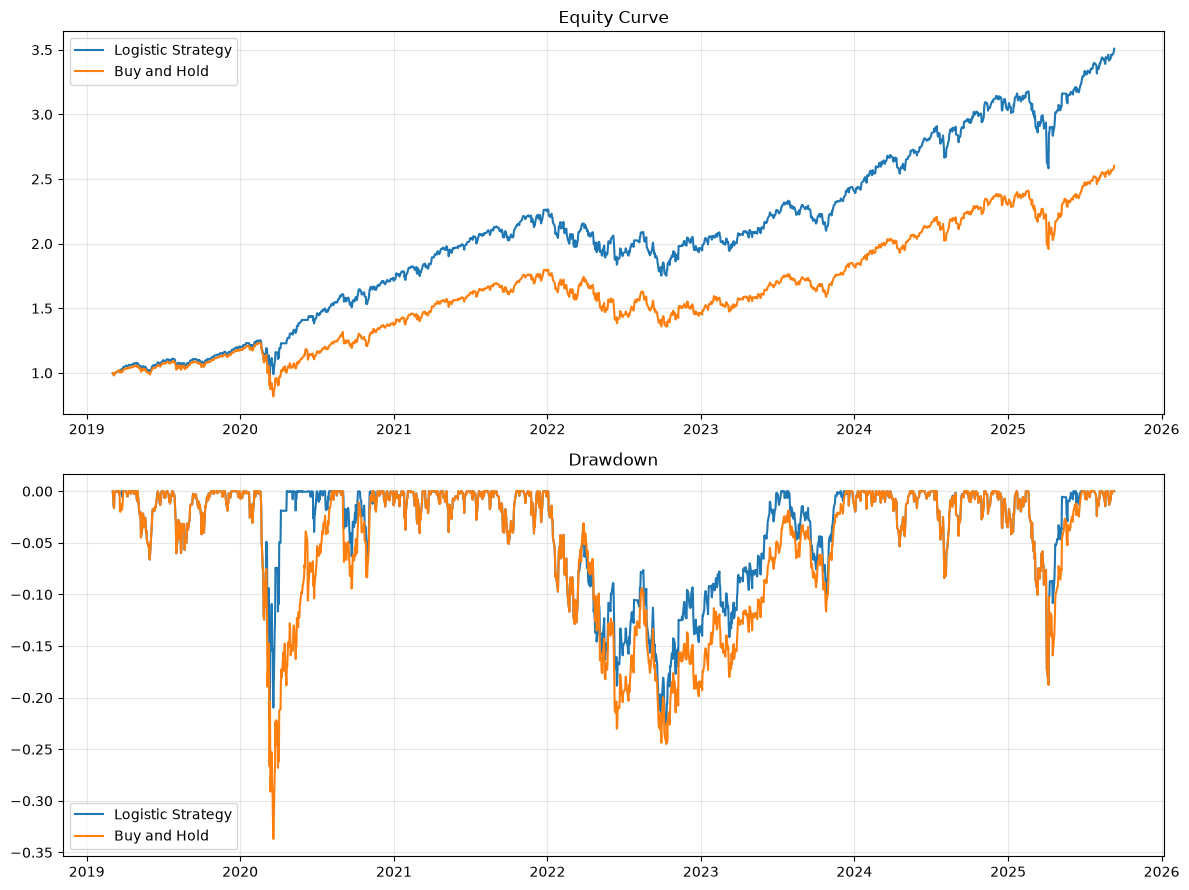

In [22]:
# 计算模型净收益与买入持有的资金曲线
backtest_df["strategy_curve"] = (
    1 + backtest_df["strategy_net"]
).cumprod()

backtest_df["buy_hold_curve"] = (
    1 + backtest_df["buy_hold_net"]
).cumprod()

# 计算两种策略相对各自历史最高资金的回撤
backtest_df["strategy_drawdown"] = (
    backtest_df["strategy_curve"]
    / backtest_df["strategy_curve"].cummax()
    - 1
)

backtest_df["buy_hold_drawdown"] = (
    backtest_df["buy_hold_curve"]
    / backtest_df["buy_hold_curve"].cummax()
    - 1
)

# 上图比较资金增长，下图比较历史回撤
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

axes[0].plot(
    backtest_df["Date"],
    backtest_df["strategy_curve"],
    label="Logistic Strategy"
)
axes[0].plot(
    backtest_df["Date"],
    backtest_df["buy_hold_curve"],
    label="Buy and Hold"
)
axes[0].set_title("Equity Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    backtest_df["Date"],
    backtest_df["strategy_drawdown"],
    label="Logistic Strategy"
)
axes[1].plot(
    backtest_df["Date"],
    backtest_df["buy_hold_drawdown"],
    label="Buy and Hold"
)
axes[1].set_title("Drawdown")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 结果解读
模型净策略明显优于买入并持有：年化收益高出约5.43个百分点，年化波动率低约1.47个百分点，Sharpe Ratio 从0.83提高到1.12，最大回撤从-33.70%降低到-22.61%，初始资金1元，模型最终约为3.51元，买入持有约为2.60元。同时可以看到交易成本确实产生了影响：单边交易145次，累计收益从277.14%下降到250.78%，年化收益从22.61%下降到21.25%，但扣除成本后仍明显超过买入持有。

逻辑回归的ROC-AUC只有0.5075，几乎没有稳定的涨跌排序能力。但分类指标对每个交易日一视同仁，回测会受到涨跌幅大小影响。可以看到，在模型持有现金的116天中：64天实际下跌，52天实际上涨。这116天如果持有SPY，复合收益为-30.96%，避开的最差单日收益为-10.94%，错过的最大单日上涨只有3.25%，所以模型并不是准确识别了大量下跌日，而是恰好避开了少数幅度很大的下跌日。这些大跌对资金曲线影响远大于普通上涨日。当前结果在经济意义上表现还不错，但我们需要确认，模型策略和买入并持有的策略相比是持续稳定的好，还是只是恰好在2020年左右跌宕剧烈的时候存在优势。

#### 2.4 按年份比较策略表现

我们将模型净收益和买入持有收益分别按年份复利，判断模型优势是否持续存在，还是集中在少数市场阶段。测试期从2019年3月开始，到2025年9月结束，因此2019年和2025年不是完整自然年。

,Strategy_Net,Buy_and_Hold,Excess_Return
Year,,,
2019,20.62%,18.41%,2.20%
2020,42.03%,15.68%,26.35%
2021,32.15%,31.28%,0.87%
2022,-13.68%,-18.99%,5.30%
2023,23.78%,26.01%,-2.24%
2024,25.36%,25.28%,0.08%
2025,15.69%,13.16%,2.53%


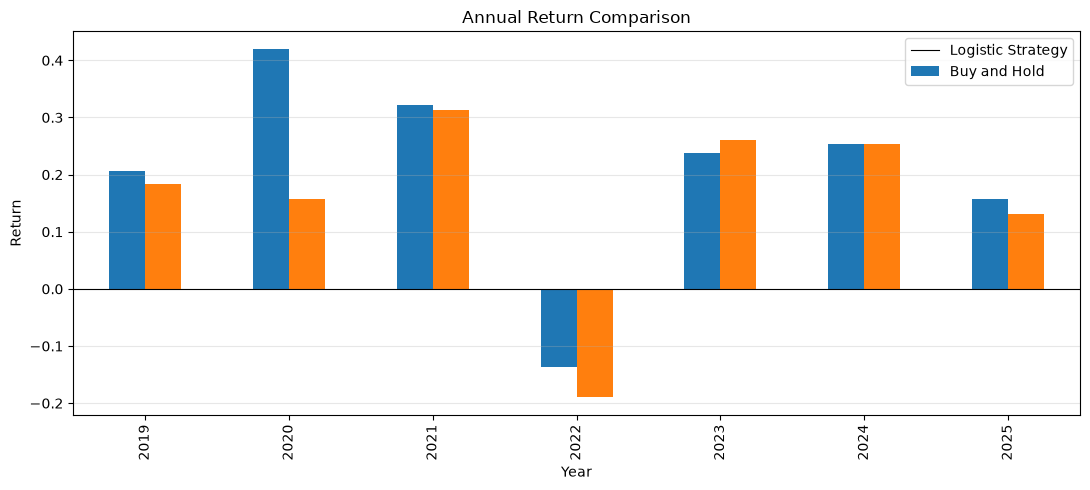

In [23]:
# 按信号产生年份计算两种策略的复合收益
annual_results = (
    backtest_df.assign(Year=backtest_df["Date"].dt.year)
    .groupby("Year")
    .agg(
        Strategy_Net=(
            "strategy_net",
            lambda returns: (1 + returns).prod() - 1
        ),
        Buy_and_Hold=(
            "buy_hold_net",
            lambda returns: (1 + returns).prod() - 1
        )
    )
)

# 正数表示该年模型净策略超过买入持有
annual_results["Excess_Return"] = (
    annual_results["Strategy_Net"]
    - annual_results["Buy_and_Hold"]
)

display(annual_results.style.format("{:.2%}"))

# 用柱状图比较每年的模型净收益与买入持有收益
annual_results[["Strategy_Net", "Buy_and_Hold"]].plot(
    kind="bar",
    figsize=(11, 5)
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Annual Return Comparison")
plt.xlabel("Year")
plt.ylabel("Return")
plt.legend(["Logistic Strategy", "Buy and Hold"])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

可以清楚的看到，模型净策略在7个年度区间中的6个超过买入持有，但超额收益主要集中在2020年，2021年和2024年的优势很小。模型在2020年和2022年的高波动或下跌市场中表现出较明显的风险规避效果，而在普通上涨年份的表现通常接近买入持有。当前结果说明策略可能具有一定的下行保护能力，但单一测试区间不足以证明其存在稳定的长期优势。

#### 2.5 查看逻辑回归系数

由于我们的模型使用标准化后的特征训练，因此系数大小可以直接比较。正系数表示该特征升高时，模型预测上涨的倾向增强；负系数表示预测上涨的倾向减弱。绝对值越大，说明该特征对模型输出的影响越强。系数描述训练数据中的条件相关关系，不代表因果关系。

,Feature,Coefficient,Absolute_Coefficient
8,intraday_return,-0.0520,0.0520
9,daily_range,-0.0445,0.0445
1,return_5d,-0.0403,0.0403
5,distance_ma_60,-0.0375,0.0375
10,volume_ratio_20d,0.0290,0.0290
4,distance_ma_20,-0.0282,0.0282
6,volatility_5d,-0.0259,0.0259
2,return_20d,-0.0120,0.0120
3,distance_ma_5,0.0102,0.0102
7,volatility_20d,-0.0019,0.0019


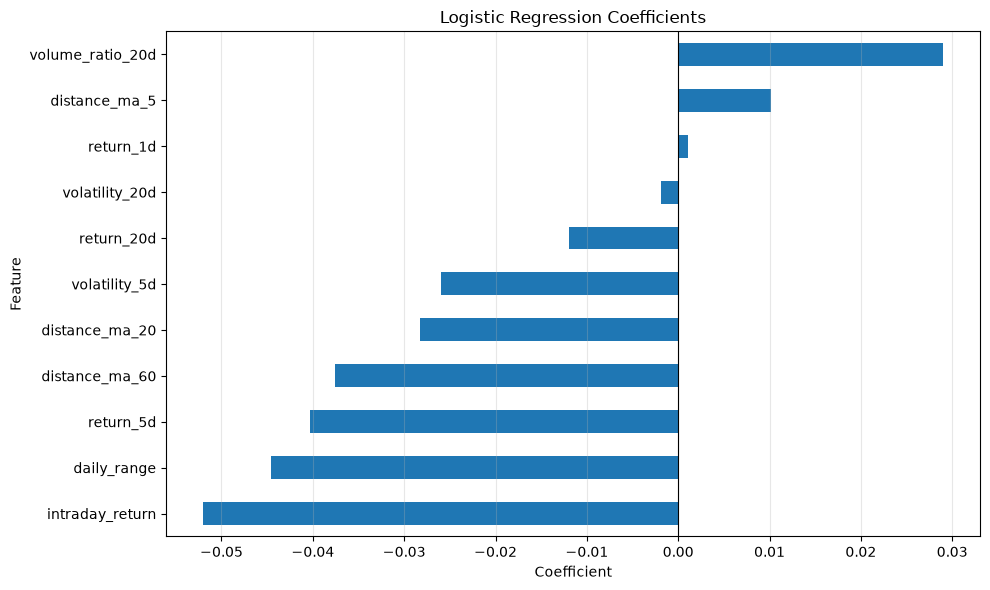

In [24]:
# 将每个标准化特征与逻辑回归学到的系数对应
coefficient_results = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": logistic_model.coef_[0]
})

# 按绝对值从大到小排列，先查看对模型影响最大的特征
coefficient_results["Absolute_Coefficient"] = (
    coefficient_results["Coefficient"].abs()
)
coefficient_results = coefficient_results.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(
    coefficient_results.style.format({
        "Coefficient": "{:.4f}",
        "Absolute_Coefficient": "{:.4f}"
    })
)

# 横向柱状图同时展示系数的方向和大小
coefficient_results.sort_values("Coefficient").plot.barh(
    x="Feature",
    y="Coefficient",
    figsize=(10, 6),
    legend=False
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

逻辑回归所有系数的绝对值都小于0.06，说明每个特征对预测概率的影响都很弱。同时模型主要表现出轻微的短期反转和高波动回避倾向，但没有发现强烈、稳定的方向预测关系。

## 2.6 逻辑回归模型总结

### 研究目标

本项目只使用SPY历史日线数据，利用当天收盘时及以前能够获得的价格、趋势、波动率和成交量特征，预测SPY下一交易日是否上涨。模型预测上涨时持有SPY，预测不涨时持有现金。不做空，也不使用杠杆。

### 数据与方法

原始数据包含8,210个交易日。数据严格按时间顺序划分：前80%用于训练，后20%用于最终测试，没有随机打乱。滚动特征完成并删除前期缺失行后，训练集包含6,509个样本，测试集包含1,641个样本，测试期为2019年3月至2025年9月。模型共使用11个特征，包括1日、5日和20日历史收益率，价格与5日、20日和60日均线的距离，5日和20日滚动波动率，日内收益率、日内振幅和20日相对成交量。所有特征先使用训练集参数进行标准化，再训练逻辑回归。

### 分类结果

始终预测上涨的基线准确率为55.39%，逻辑回归准确率为56.12%，只提高了0.73个百分点，即在1,641个测试样本中多正确预测12天。模型ROC-AUC为0.5075，接近随机排序的0.5，说明当前特征对下一日涨跌方向的预测能力很弱。所有标准化特征的逻辑回归系数绝对值都小于0.06，也支持这一结论。模型主要表现出轻微的短期反转和高波动回避倾向，而不是强烈、稳定的方向信号。

### 回测结果

回测采用0或1仓位，并为每次买入或卖出扣除5个基点的交易成本。模型共发生145次单边交易。扣除成本后，模型策略累计收益为250.78%，年化收益为21.25%，年化波动率为18.72%，Sharpe Ratio为1.12，最大回撤为-22.61%。同期买入并持有SPY的累计收益为160.25%，年化收益为15.82%，年化波动率为20.19%，Sharpe Ratio为0.83，最大回撤为-33.70%。

模型在测试期约93%的日期持有SPY，只在116个日期持有现金。分类准确率虽然只略高于基线，但这116个日期如果持有SPY，复合收益为-30.96%。因此，模型回测表现较好的主要原因不是稳定预测了多数交易日的方向，而是避开了少数幅度较大的下跌。

### 年度稳定性

模型净策略在7个年度区间中的6个超过买入并持有，但超额收益主要集中在2020年，当年模型超过买入持有26.35个百分点。2022年模型也减少了约5.30个百分点的亏损；2021年和2024年的差异很小，2023年则落后买入持有2.24个百分点。结果表明模型可能具有一定的下行保护能力。

### 局限性

本次项目中只进行了单次训练集与测试集划分，没有使用Walk-forward验证；模型优势明显依赖2020年等少数高波动阶段；回测假设可以根据当天完整收盘数据按当天收盘价建立仓位，真实交易中存在执行时间和滑点问题；现金收益假设为0，交易成本固定为5个基点；项目只使用SPY自身数据，没有验证结果在其他资产或市场阶段是否成立。

### 结论

我们使用逻辑回归完成了从数据读取、时间划分、特征提取、逻辑回归、分类评估到含交易成本回测的完整流程。结果说明，较弱的方向分类模型仍可能因为避开少数大幅下跌而改善资金曲线和回撤，但当前的数据结果不能证明模型具有可持续的预测优势。之后，我们会在训练期内部使用Walk-forward验证，然后使用Walk-forward结果选择随机森林参数，训练随机森林模型。然后将逻辑回归的结果作为基线，与随机森林比较。

## 3 随机森林